In [195]:
from neural_priors.utils.data import Subject, get_all_subject_ids

from tqdm.contrib.itertools import product
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

bids_folder = '/data/ds-neuralpriors'
roi = 'NPCr'

In [196]:
natural_pars = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])

logspace_pars = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
# logspace_pars = logspace_pars.rename(index=lambda x: f"Model {x}", level="model_label").rename_axis(index={'subject_id':'subject'})

pars = pd.concat([natural_pars, logspace_pars], keys=['natural', 'logspace'], names=['space'], axis=0)
pars.rename_axis(index={'level_3':'voxel', None:'voxel', 'subject_id':'subject'}, inplace=True)

In [197]:
cvr2 = pars['cvr2']
cvr2.columns = ['cvr2']
cvr2 = cvr2.unstack(['space', 'model_label'])#['cvr2'].drop([ 5, 6, 7, 8], axis=1)

mask = cvr2.gt(0).any(axis=1) & cvr2.notna().all(axis=1)

masked_cvr2 = cvr2[mask]

In [198]:
missing = cvr2.groupby('subject').mean().stack([1,2], dropna=False).isna()
missing[missing.values].groupby(['model_label', 'space', 'subject']).size().unstack(['space', 'model_label'])

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/4112589720.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  missing = cvr2.groupby('subject').mean().stack([1,2], dropna=False).isna()


space       logspace               
model_label       3    4    5    10
subject                            
1                NaN  1.0  1.0  1.0
2                NaN  1.0  1.0  1.0
3                NaN  1.0  1.0  1.0
4                NaN  1.0  1.0  1.0
5                NaN  1.0  1.0  1.0
6                NaN  1.0  1.0  1.0
7                NaN  1.0  1.0  1.0
8                NaN  1.0  1.0  1.0
9                NaN  1.0  1.0  1.0
10               NaN  1.0  1.0  1.0
12               NaN  1.0  1.0  1.0
13               NaN  1.0  1.0  1.0
14               NaN  1.0  1.0  1.0
15               NaN  1.0  1.0  1.0
16               NaN  1.0  1.0  1.0
17               NaN  1.0  1.0  1.0
18               NaN  1.0  1.0  1.0
19               NaN  1.0  1.0  1.0
20               NaN  1.0  1.0  1.0
21               NaN  1.0  1.0  1.0
22               NaN  1.0  1.0  1.0
24               NaN  1.0  1.0  1.0
25               NaN  1.0  1.0  1.0
26               NaN  1.0  1.0  1.0
27               NaN  1.0  1.0  1.0
28               NaN  1.0  1.0  1.0
29               NaN  1.0  1.0  1.0
30               NaN  1.0  1.0  1.0
31               NaN  1.0  1.0  1.0
32               NaN  1.0  1.0  1.0
33               1.0  1.0  1.0  1.0
34               1.0  1.0  1.0  1.0
35               NaN  1.0  1.0  1.0
36               NaN  1.0  1.0  1.0
37               1.0  1.0  1.0  1.0
38               1.0  1.0  1.0  1.0
39               1.0  1.0  1.0  1.0
40               1.0  1.0  1.0  1.0
41               1.0  1.0  1.0  1.0

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/2496876894.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']


Text(0.5, 1.0, 'Proportion of voxels with cvR2 > 0.0')

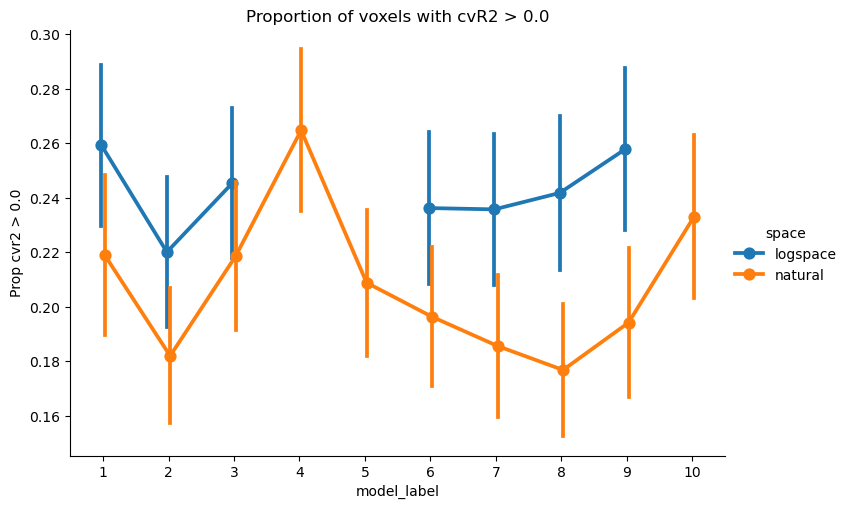

In [199]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]

tmp = (tmp > 0.0).groupby(['subject', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

g = sns.catplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', kind='point', aspect=1.5, errorbar='se', dodge=True)

# g.set(xlabel=None)

plt.title("Proportion of voxels with cvR2 > 0.0")

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/632516559.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sns.catplot(data=cvr2[mask].stack([1,2])['cvr2'].groupby(['subject', 'space', 'model_label']).mean().reset_index(),


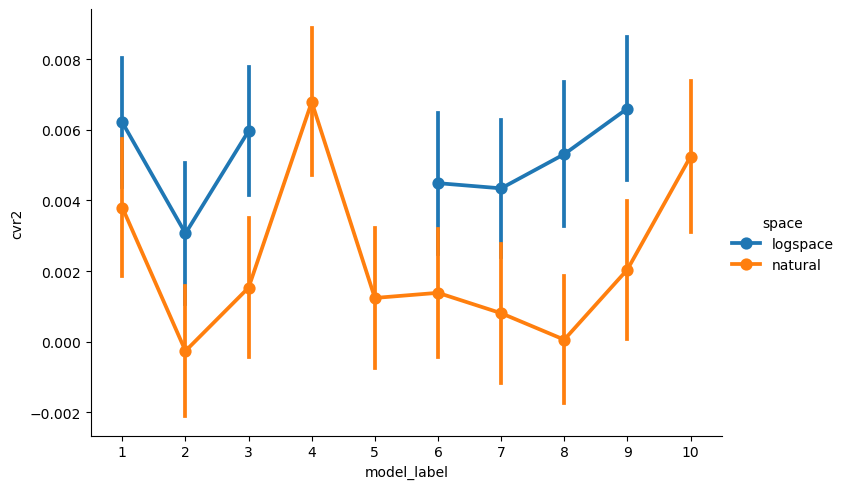

In [200]:
mask = cvr2.gt(0).any(axis=1)


sns.catplot(data=cvr2[mask].stack([1,2])['cvr2'].groupby(['subject', 'space', 'model_label']).mean().reset_index(),
            x='model_label', y='cvr2', hue='space', kind='point', aspect=1.5, errorbar='se')

Text(0.5, 1.0, 'Proportion of winning model (over all other models)')

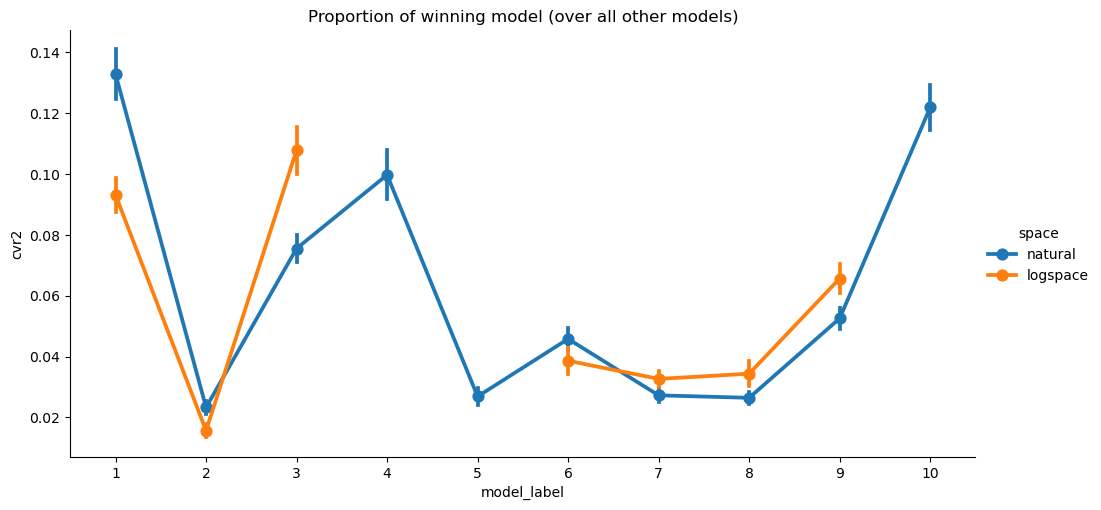

In [201]:
hue_order = ['natural', 'logspace']
winning_model = cvr2['cvr2'].idxmax(axis=1)
winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2.columns.names[1:])

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='point', aspect=2, errorbar='se',
            hue='space', hue_order=hue_order)
# plt.axhline(0.5, color='black', linestyle='--')

plt.title('Proportion of winning model (over all other models)')

In [202]:
winning_model = cvr2['cvr2'][[('logspace', 1), ('logspace', 4)]].idxmax(axis=1)
winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=2, errorbar='se',
            hue='space', hue_order=hue_order)
# plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in log-space')

KeyError: "[('logspace', 4)] not in index"

In [ ]:
winning_model = cvr2['cvr2'][[('natural', 4), ('logspace', 4)]].idxmax(axis=1)
winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=2, errorbar='se',
            hue='space', hue_order=hue_order)
# plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 4 in natural-space vs model 4 log-space')

KeyError: "[('logspace', 4)] not in index"

In [ ]:
winning_model = cvr2['cvr2'][[('logspace', 4), ('logspace', 9)]].idxmax(axis=1)
winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=2, errorbar='se',
            hue='space', hue_order=hue_order)
# plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 4 in natural-space vs model 4 log-space')

KeyError: "[('logspace', 4)] not in index"

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 4 in natural-space vs model 10 log-space')

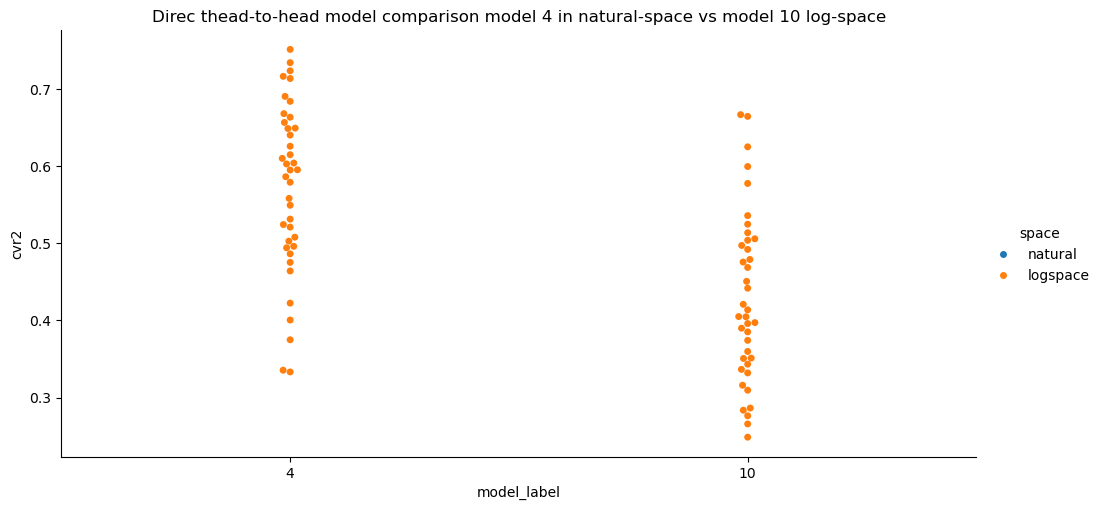

In [ ]:
winning_model = cvr2['cvr2'][[('logspace', 4), ('logspace', 10)]].idxmax(axis=1)
winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=2, errorbar='se',
            hue='space', hue_order=hue_order)
# plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 4 in natural-space vs model 10 log-space')

In [ ]:
mask

subject  voxel
1        0        False
         1        False
         2        False
         3        False
         4        False
                  ...  
41       689       True
         690       True
         691       True
         692      False
         693       True
Length: 30533, dtype: bool

In [ ]:
pars

parameter                                  mu                   sd            \
range                                    wide     narrow      wide    narrow   
space    subject model_label voxel                                             
natural  1       1           0      10.943486  10.943486  1.389957  1.389957   
                             1      45.297676  45.297676  1.098172  1.098172   
                             2      45.338240  45.338240  1.067531  1.067531   
                             3      45.309338  45.309338  1.089480  1.089480   
                             4      11.575078  11.575078  1.056056  1.056056   
...                                       ...        ...       ...       ...   
logspace 41      10          689     0.555472   0.555472  3.630056  3.109732   
                             690     2.050501   2.050501  0.138006  0.179778   
                             691     0.683849   0.683849  3.678903  3.150510   
                             692     1.432152   1.432152  0.963390  0.919342   
                             693     0.886088   0.886088  3.395163  2.913976   

parameter                          amplitude            baseline            \
range                                   wide    narrow      wide    narrow   
space    subject model_label voxel                                           
natural  1       1           0      0.293845  0.293845 -0.118108 -0.118108   
                             1      0.034831  0.034831 -0.487767 -0.487767   
                             2      0.028312  0.028312 -0.477014 -0.477014   
                             3      0.035011  0.035011 -0.271681 -0.271681   
                             4      0.374618  0.374618 -0.110368 -0.110368   
...                                      ...       ...       ...       ...   
logspace 41      10          689    1.248392  1.248392 -0.627629 -0.627629   
                             690    0.223219  0.223219  0.281405  0.281405   
                             691    1.360044  1.360044 -0.850198 -0.850198   
                             692    0.391514  0.391514 -0.156351 -0.156351   
                             693    1.023951  1.023951 -0.743600 -0.743600   

parameter                                     r2      cvr2  
range                                        nan       nan  
space    subject model_label voxel                          
natural  1       1           0      8.020937e-03 -0.019104  
                             1     -1.192093e-07 -0.016332  
                             2      0.000000e+00 -0.009276  
                             3     -1.192093e-07 -0.011063  
                             4      8.203387e-03 -0.013769  
...                                          ...       ...  
logspace 41      10          689    2.247077e-02  0.011012  
                             690    3.627121e-03 -0.020376  
                             691    2.312553e-02  0.012688  
                             692    1.432180e-02 -0.012010  
                             693    1.121664e-02  0.004150  

[607434 rows x 10 columns]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/513396804.py:11: RuntimeWarning: divide by zero encountered in log
  plt.plot(x, np.log(x), c='r')


(1.0, 3.5)

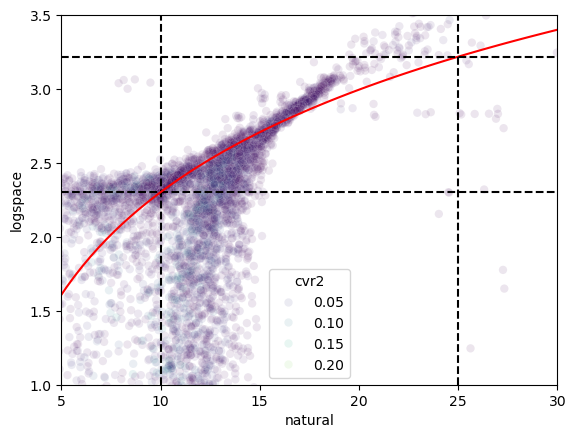

In [ ]:
mask = pars[('cvr2', 'nan')].gt(0)
tmp = pars[mask.values].xs(4, level='model_label')[('mu', 'narrow')].unstack('space')
tmp['cvr2'] = pars[mask.values].xs(4, level='model_label').groupby(['subject', 'voxel'])['cvr2'].mean()
sns.scatterplot(tmp.reset_index(), x='natural', y='logspace', alpha=0.1, hue='cvr2', palette='viridis')

plt.axvline(10, c='k', ls='--')
plt.axhline(np.log(10), c='k', ls='--')


x = np.linspace(0, 40, 100)
plt.plot(x, np.log(x), c='r')
plt.axvline(25, c='k', ls='--')
plt.axhline(np.log(25), c='k', ls='--')

plt.xlim(5,  30)
plt.ylim(1, 3.5)

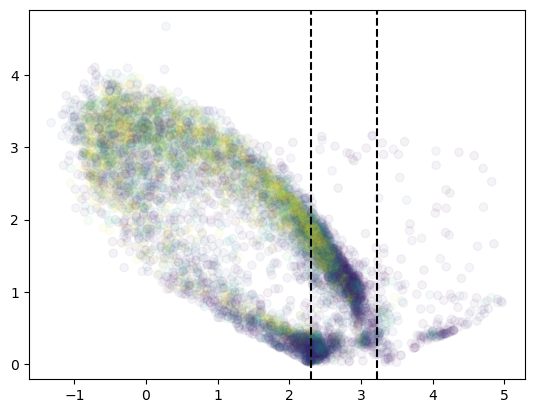

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

# Define the colormap and normalization
norm = mcolors.Normalize(vmin=0.0, vmax=0.05)
cmap = plt.cm.viridis

tmp = pars.loc['logspace'].xs(4, level='model_label').xs('narrow', axis=1, level='range')
tmp['cvr2'] = pars.loc['natural'].xs(4, level='model_label').groupby(['subject', 'voxel'])['cvr2'].mean()

tmp = tmp[tmp['cvr2'] > 0]

# Apply normalization to the hue values
tmp['cvr2_color'] = tmp['cvr2'].map(lambda x: cmap(norm(x)))

# Create figure and axis
fig, ax = plt.subplots()

# Scatter plot with manually mapped colors
scatter = ax.scatter(
    tmp['mu'],
    tmp['sd'],
    c=tmp['cvr2'],  # Pass the raw values
    cmap=cmap,
    norm=norm,  # Apply the normalization
    alpha=0.05,
    edgecolor=None
)

# Create a colorbar
# cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("cvr2")

# Add vertical lines
plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(25), c='k', ls='--')

plt.show()


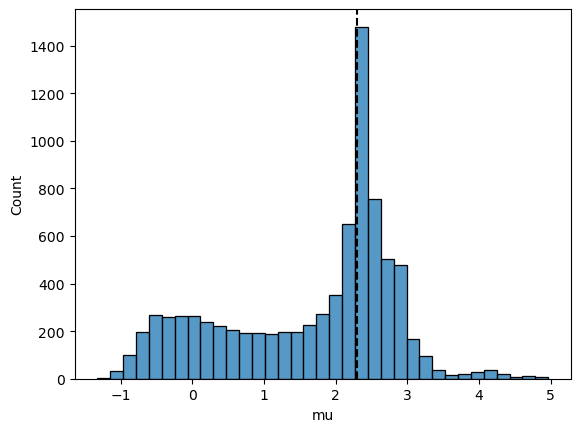

In [ ]:
sns.histplot(tmp['mu'])

plt.axvline(np.log(10), c='k', ls='--')

In [ ]:
tmp

parameter            mu        sd  amplitude  baseline      cvr2
subject voxel                                                   
1       10     2.490949  0.169442   0.619600 -0.468931  0.018232
        13    -0.225211  2.271860   1.870979 -0.955214  0.021661
        16     2.463982  0.168306   0.471472 -0.292767  0.013175
        19     2.459766  0.120146   0.481401 -0.284899  0.011107
        22     0.431604  2.102613   1.327263 -0.904266  0.024367
...                 ...       ...        ...       ...       ...
41      681    2.174712  2.036120   1.557184 -1.210389  0.026876
        682    2.516782  1.497580   1.077321 -0.834488  0.020276
        683    2.336166  1.823386   0.978958 -0.689231  0.018232
        684    2.646447  1.350920   1.157720 -0.880817  0.018255
        691    2.252207  2.010718   1.236374 -0.923142  0.015091

[5225 rows x 5 columns]

parameter             mu        sd  amplitude  baseline      cvr2
subject voxel                                                    
1       10     11.826234  1.291291   0.693560 -0.458097  0.018232
        13     11.722606  1.292519   0.658302 -0.354816  0.021661
        14     11.841642  1.172022   0.602013 -0.613250  0.000334
        16     11.511793  1.333574   0.469157 -0.281016  0.013175
        17     11.584733  1.171649   0.579704 -0.425940  0.007712
...                  ...       ...        ...       ...       ...
41      684    14.141085  5.886398   0.264921  0.027854  0.018255
        688    14.055022  7.757670   0.292565 -0.135919  0.008892
        689    11.720959  6.521481   0.225783  0.187710  0.000292
        691    12.148956  7.479709   0.283475  0.027834  0.015091
        693    12.074364  8.401328   0.259730 -0.121351  0.005679

[8181 rows x 5 columns]

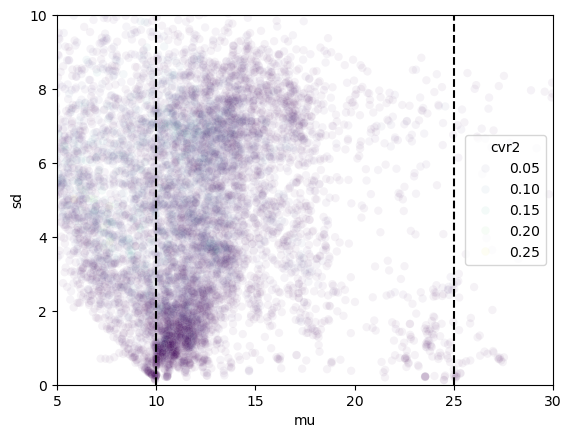

In [ ]:

tmp = pars.loc['natural'].xs(4, level='model_label').xs('narrow', axis=1, level='range')
tmp['cvr2'] = pars.loc['natural'].xs(4, level='model_label').groupby(['subject', 'voxel'])['cvr2'].mean()

tmp = tmp[tmp['cvr2'] > 0]
sns.scatterplot(tmp.reset_index(), x='mu', y='sd', palette='viridis', alpha=0.05, hue='cvr2')
plt.axvline(10, c='k', ls='--')
plt.axvline(25, c='k', ls='--')
# plt.axhline(1, c='k', ls='--')

plt.xlim(5, 30)
plt.ylim(0, 10)

tmp

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/2898842485.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu['cvr2'] = tmp[('cvr2', 'nan')]


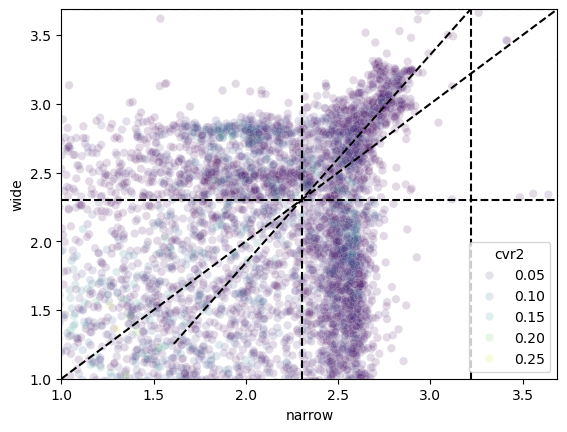

In [ ]:
tmp = pars.loc['logspace'].xs(8, level='model_label')

mu = tmp['mu']
mu['cvr2'] = tmp[('cvr2', 'nan')]

mu = mu[mu['cvr2'] > 0]

sns.scatterplot(mu.reset_index(), x='narrow', y='wide', palette='viridis', alpha=0.15, hue='cvr2')

plt.xlim(1, np.log(40))
plt.ylim(1, np.log(40))
plt.plot([1, np.log(40)], [1, np.log(40)], c='k', ls='--')

x_vals = np.log([5, 40])
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
y_vals = np.log(10) + slope * (x_vals - np.log(10))  # y = y0 + slope * (x - x0)

plt.plot(x_vals, y_vals, c='k', ls='--')


plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(25), c='k', ls='--')

plt.axhline(np.log(10), c='k', ls='--')
plt.axhline(np.log(40), c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/50650554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu['cvr2'] = tmp[('cvr2', 'nan')]


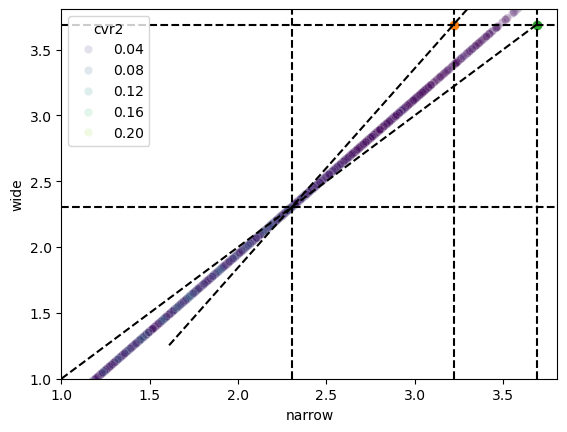

In [ ]:
tmp = pars.loc['logspace'].xs(4, level='model_label')

mu = tmp['mu']
mu['cvr2'] = tmp[('cvr2', 'nan')]

mu = mu[mu['cvr2'] > 0]

sns.scatterplot(mu.reset_index(), x='narrow', y='wide', palette='viridis', alpha=0.15, hue='cvr2')

plt.xlim(1, np.log(45))
plt.ylim(1, np.log(45))
plt.plot([1, np.log(40)], [1, np.log(40)], c='k', ls='--')

x_vals = np.log([5, 40])
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
y_vals = np.log(10) + slope * (x_vals - np.log(10))  # y = y0 + slope * (x - x0)

plt.plot(x_vals, y_vals, c='k', ls='--')


plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(25), c='k', ls='--')
plt.axvline(np.log(40), c='k', ls='--')

plt.axhline(np.log(10), c='k', ls='--')
plt.axhline(np.log(40), c='k', ls='--')

plt.scatter(np.log(25), np.log(40))
plt.scatter(np.log(40), np.log(40))

In [ ]:
range_increase_log_space = np.log(40) - np.log(10) / (np.log(25) - np.log(10)) # (2)

In [ ]:
range_increase_log_space

1.1759378593818748

In [ ]:
range_increase_log_space = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10)) # (2)

range_increase_log_space

1.5129415947320604

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/1359090619.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu['cvr2'] = tmp[('cvr2', 'nan')]


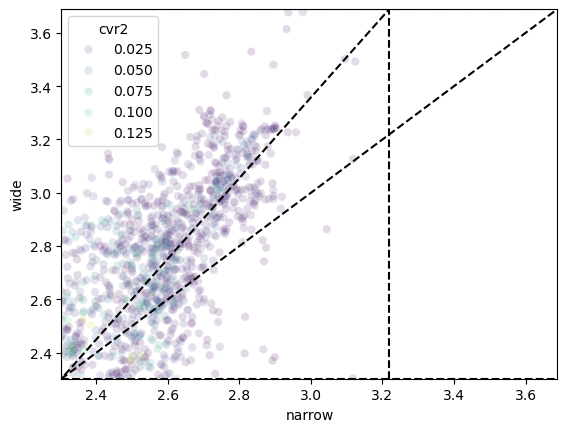

In [ ]:
tmp = pars.loc['logspace'].xs(8, level='model_label')

mu = tmp['mu']
mu['cvr2'] = tmp[('cvr2', 'nan')]

mu = mu[mu['cvr2'] > 0]

mu = mu[(mu['narrow'] > np.log(10)) & (mu['narrow'] < np.log(25)) & (mu['wide'] > np.log(10)) & (mu['wide'] < np.log(40))]

sns.scatterplot(mu.reset_index(), x='narrow', y='wide', palette='viridis', alpha=0.15, hue='cvr2')

plt.xlim(np.log(10), np.log(40))
plt.ylim(np.log(10), np.log(40))
plt.plot([1, np.log(40)], [1, np.log(40)], c='k', ls='--')

x_vals = np.log([5, 40])
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
y_vals = np.log(10) + slope * (x_vals - np.log(10))  # y = y0 + slope * (x - x0)

plt.plot(x_vals, y_vals, c='k', ls='--')


plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(25), c='k', ls='--')

plt.axhline(np.log(10), c='k', ls='--')
plt.axhline(np.log(40), c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/3690238466.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sd['cvr2'] = tmp[('cvr2', 'nan')]


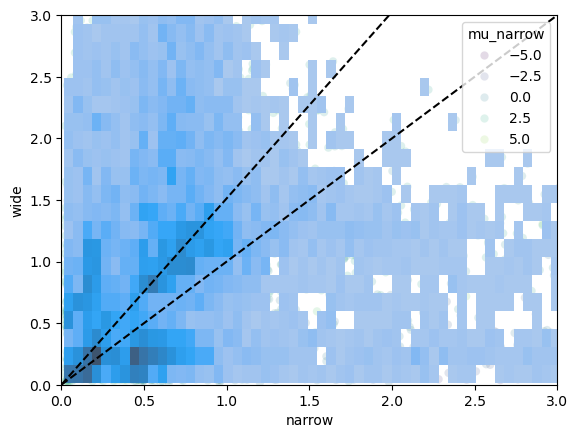

In [ ]:
tmp = pars.loc['logspace'].xs(8, level='model_label')

sd = tmp['sd']
sd['cvr2'] = tmp[('cvr2', 'nan')]

sd = sd[sd['cvr2'] > 0]

sd['mu_narrow'] = pars.loc['logspace'].xs(8, level='model_label')['mu']['narrow']

sns.scatterplot(sd.reset_index(), x='narrow', y='wide', palette='viridis', alpha=0.15, hue='mu_narrow')
sns.histplot(sd.reset_index(), x='narrow', y='wide')

plt.xlim(0, 3)
plt.ylim(0, 3)
plt.plot([0, 3], [0, 3], c='k', ls='--')

x_vals = [0, 3]
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
y_vals = 0.0 + slope * np.array(x_vals)  # y = y0 + slope * (x - x0)

plt.plot(x_vals, y_vals, c='k', ls='--')


# plt.axvline(np.log(10), c='k', ls='--')
# plt.axvline(np.log(25), c='k', ls='--')

# plt.axhline(np.log(10), c='k', ls='--')
# plt.axhline(np.log(40), c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60834/3503319153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sd['cvr2'] = tmp[('cvr2', 'nan')]


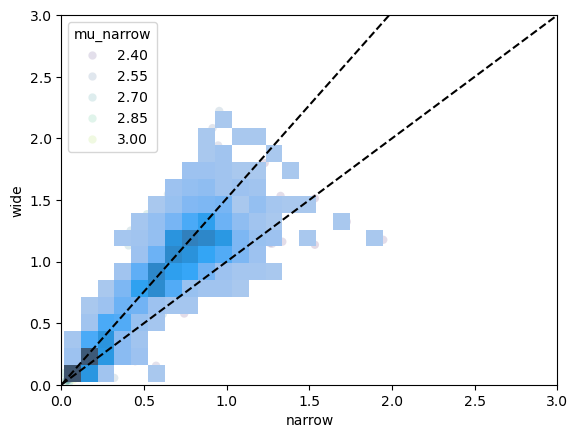

In [ ]:
tmp = pars.loc['logspace'].xs(8, level='model_label')

sd = tmp['sd']
sd['cvr2'] = tmp[('cvr2', 'nan')]

sd = sd[sd['cvr2'] > 0]

sd['mu_narrow'] = pars.loc['logspace'].xs(8, level='model_label')['mu']['narrow']
sd['mu_wide'] = pars.loc['logspace'].xs(8, level='model_label')['mu']['wide']

sd = sd[(sd['mu_narrow'] > np.log(10) ) & (sd['mu_narrow'] < np.log(25))]
sd = sd[(sd['mu_wide'] > np.log(10) ) & (sd['mu_wide'] < np.log(40))]


sns.scatterplot(sd.reset_index(), x='narrow', y='wide', palette='viridis', alpha=0.15, hue='mu_narrow')
sns.histplot(sd.reset_index(), x='narrow', y='wide')

plt.xlim(0, 3)
plt.ylim(0, 3)
plt.plot([0, 3], [0, 3], c='k', ls='--')

x_vals = [0, 3]
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
y_vals = 0.0 + slope * np.array(x_vals)  # y = y0 + slope * (x - x0)

plt.plot(x_vals, y_vals, c='k', ls='--')


# plt.axvline(np.log(10), c='k', ls='--')
# plt.axvline(np.log(25), c='k', ls='--')

# plt.axhline(np.log(10), c='k', ls='--')
# plt.axhline(np.log(40), c='k', ls='--')

In [ ]:
# OLD

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/2902299427.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/2902299427.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]


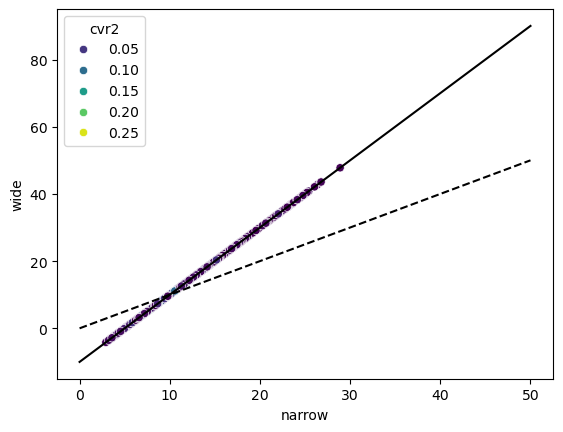

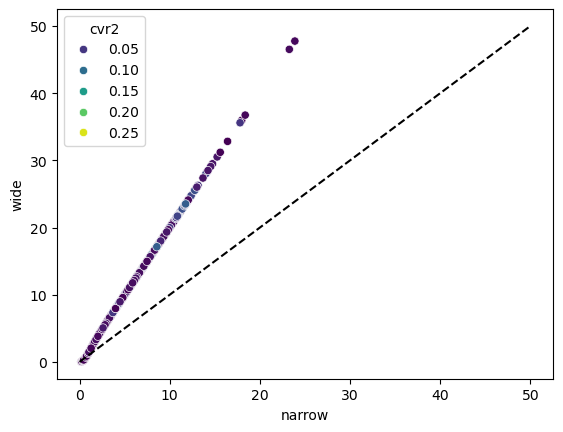

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tmp = pars.xs('Model 4', level='model_label')
mask = tmp[('cvr2')].iloc[:, 0] > 0.01


tmp2 = tmp['mu']
tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]

sns.scatterplot(data=tmp2[mask], x='narrow', y='wide', hue='cvr2', palette='viridis')

plt.plot([0, 50], [0*2-10, 50*2 - 10], c='k')
plt.plot([0, 50], [0, 50], 'k--')

tmp2 = tmp['sd']
tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]

plt.figure()
sns.scatterplot(data=tmp2[mask], x='narrow', y='wide', hue='cvr2', palette='viridis')

plt.plot([0, 50], [0, 50], 'k--')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/3972048696.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/3972048696.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(data=tmp2[mask], x='narrow', y='wide', palette='viridis')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/3972048696.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view

(0.0, 40.0)

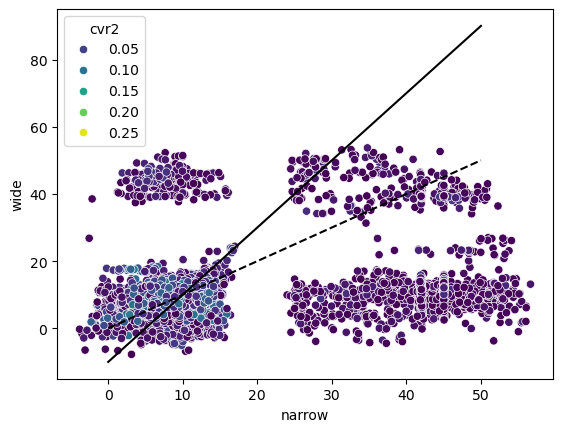

<Figure size 640x480 with 0 Axes>

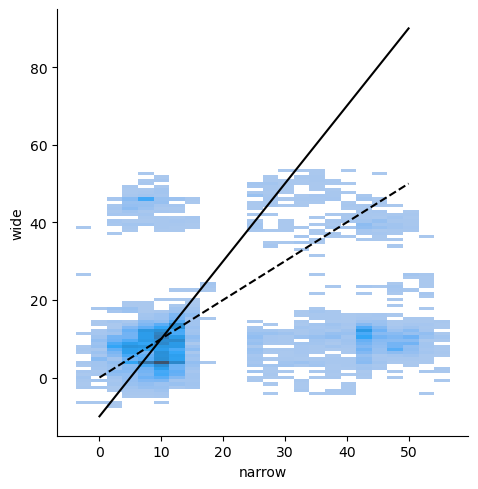

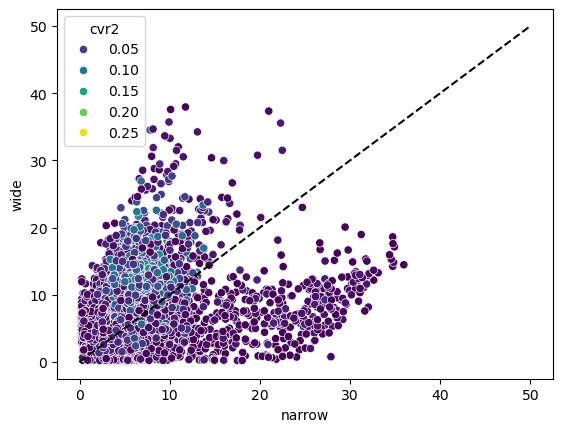

<Figure size 640x480 with 0 Axes>

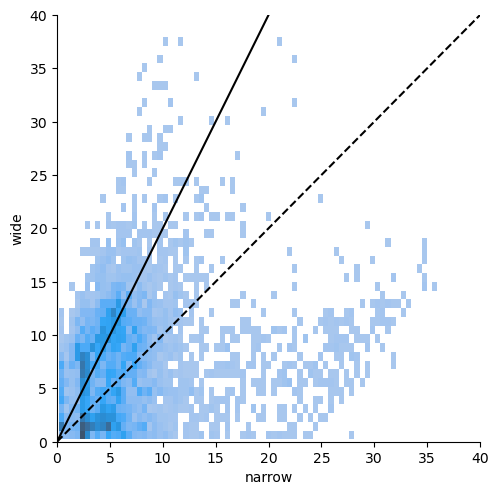

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tmp = pars.xs('Model 8', level='model_label')
mask = tmp[('cvr2')].iloc[:, 0] > 0.0


tmp2 = tmp['mu']
tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]

sns.scatterplot(data=tmp2[mask], x='narrow', y='wide', hue='cvr2', palette='viridis')

plt.plot([0, 50], [0*2-10, 50*2 - 10], c='k')
plt.plot([0, 50], [0, 50], 'k--')

plt.figure()
sns.displot(data=tmp2[mask], x='narrow', y='wide', palette='viridis')

plt.plot([0, 50], [0*2-10, 50*2 - 10], c='k')
plt.plot([0, 50], [0, 50], 'k--')

tmp2 = tmp['sd']
tmp2['cvr2'] = tmp[('cvr2')].iloc[:, 0]

plt.figure()
sns.scatterplot(data=tmp2[mask], x='narrow', y='wide', hue='cvr2', palette='viridis')

plt.plot([0, 50], [0, 50], 'k--')

plt.figure()
sns.displot(data=tmp2[mask], x='narrow', y='wide', palette='viridis')

plt.plot([0, 50], [0, 50], 'k--')
plt.plot([0, 50], [0, 50*2], c='k')

plt.xlim(0,40)
plt.ylim(0,40)

Propotion of non-monotonically tuned voxels: 0.563989732306564


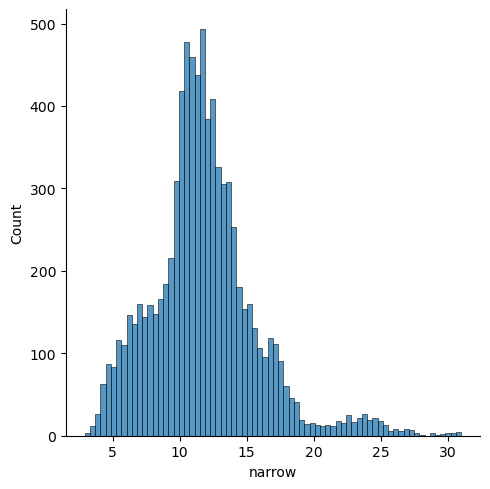

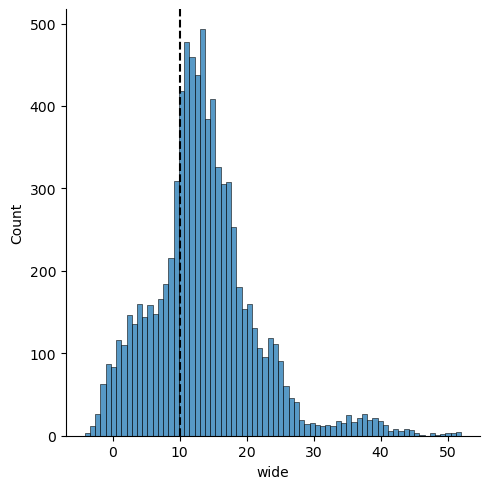

In [ ]:
mu = pars.xs('Model 4', level='model_label')['mu']

cvr2 = pars.xs('Model 4', level='model_label')['cvr2']
mask = cvr2.iloc[:, 0] > 0.0

sns.displot(mu[mask]['narrow'])
sns.displot(mu[mask]['wide'])

# sns.displot(mu[mask].stack(), hue=mu[mask].stack().index.get_level_values('range'))

plt.axvline(10., c='k', ls='--')

print(f'Propotion of non-monotonically tuned voxels: {((mu[mask]["narrow"] > 11.0) & (mu[mask]["wide"] < 40.0) ).mean()}')

In [ ]:
range_increase_natural_space = (40 - 10) / (25 - 10) # (2)
range_increase_log_space = np.log(40) - np.log(10) / (np.log(25) - np.log(10)) # (2)

In [ ]:
range_increase_natural_space, range_increase_log_space

(2.0, 1.1759378593818748)

In [ ]:
np.log(30)

3.4011973816621555

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/1066276934.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mu[mask]['narrow'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/1066276934.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mu[mask]['wide'])


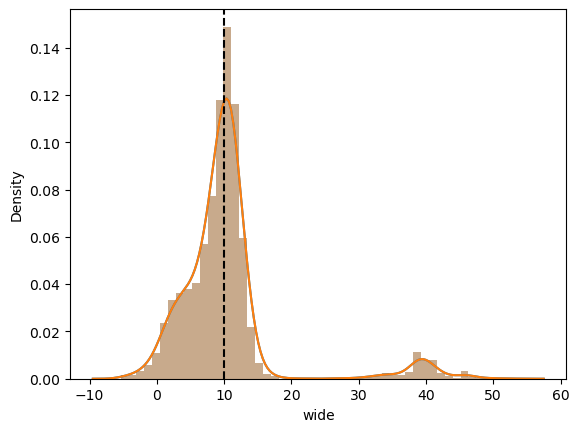

In [ ]:
mu = pars.xs('Model 1', level='model_label')['mu']

cvr2 = pars.xs('Model 1', level='model_label')['cvr2']
mask = cvr2.iloc[:, 0] > 0.0

sns.distplot(mu[mask]['narrow'])
sns.distplot(mu[mask]['wide'])

plt.axvline(10., c='k', ls='--')

In [ ]:
pars

parameter                                  mu                   sd            \
range                                    wide     narrow      wide    narrow   
space    subject model_label voxel                                             
natural  1       1           0      10.943486  10.943486  1.389957  1.389957   
                             1      45.297676  45.297676  1.098172  1.098172   
                             2      45.338240  45.338240  1.067531  1.067531   
                             3      45.309338  45.309338  1.089480  1.089480   
                             4      11.575078  11.575078  1.056056  1.056056   
...                                       ...        ...       ...       ...   
logspace 41      10          689     0.555472   0.555472  3.630056  3.109732   
                             690     2.050501   2.050501  0.138006  0.179778   
                             691     0.683849   0.683849  3.678903  3.150510   
                             692     1.432152   1.432152  0.963390  0.919342   
                             693     0.886088   0.886088  3.395163  2.913976   

parameter                          amplitude            baseline            \
range                                   wide    narrow      wide    narrow   
space    subject model_label voxel                                           
natural  1       1           0      0.293845  0.293845 -0.118108 -0.118108   
                             1      0.034831  0.034831 -0.487767 -0.487767   
                             2      0.028312  0.028312 -0.477014 -0.477014   
                             3      0.035011  0.035011 -0.271681 -0.271681   
                             4      0.374618  0.374618 -0.110368 -0.110368   
...                                      ...       ...       ...       ...   
logspace 41      10          689    1.248392  1.248392 -0.627629 -0.627629   
                             690    0.223219  0.223219  0.281405  0.281405   
                             691    1.360044  1.360044 -0.850198 -0.850198   
                             692    0.391514  0.391514 -0.156351 -0.156351   
                             693    1.023951  1.023951 -0.743600 -0.743600   

parameter                                     r2      cvr2  
range                                        nan       nan  
space    subject model_label voxel                          
natural  1       1           0      8.020937e-03 -0.019104  
                             1     -1.192093e-07 -0.016332  
                             2      0.000000e+00 -0.009276  
                             3     -1.192093e-07 -0.011063  
                             4      8.203387e-03 -0.013769  
...                                          ...       ...  
logspace 41      10          689    2.247077e-02  0.011012  
                             690    3.627121e-03 -0.020376  
                             691    2.312553e-02  0.012688  
                             692    1.432180e-02 -0.012010  
                             693    1.121664e-02  0.004150  

[607434 rows x 10 columns]

In [ ]:
sd = pars.xs('Model 8', level='model_label')['sd']

cvr2 = pars.xs('Model 8', level='model_label')['cvr2']
mask = cvr2.iloc[:, 0] > 0.0

sns.distplot(sd[mask]['narrow'])
sns.distplot(sd[mask]['wide'])

plt.axvline(10., c='k', ls='--')

KeyError: 'Model 8'

In [ ]:
from itertools import product as product_

models = [f'Model {ix}' for ix in range(1, 10)]

cvr2 = pars['cvr2'].iloc[:, 0].unstack('model_label')

mask = (cvr2 > 0.0).any(axis=1)

result = []
for model1, model2 in product_(models, models):

    if model1 != model2:
        tmp = cvr2[mask][[model1, model2]].dropna()

        if len(tmp) > 0:
            winner = tmp.idxmax(axis=1)
            prop_winning_model = winner.value_counts(normalize=True)
            result.append({'model1': model1, 'model2': model2, 'win_model1': prop_winning_model.loc[model1]})
    else:
        result.append({'model1': model1, 'model2': model2, 'win_model1': 0.5})

result = pd.DataFrame(result).set_index(['model1', 'model2'])
cmap = plt.get_cmap('RdBu_r')
cmap.set_bad(color='black')  # Set NaN values to black

sns.heatmap(result.unstack('model2'), cmap=cmap, vmin=.3, vmax=.7)

KeyError: "None of [Index(['Model 1', 'Model 2'], dtype='object', name='model_label')] are in the [columns]"

In [ ]:
sns.displot(data=cvr2['cvr2'], x='Model 1', y='Model 4')
plt.plot([-.1, .1], [-.1, .1], 'k--')
plt.axhline(0, c='k')
plt.axvline(0, c='k')

KeyError: 'cvr2'

In [ ]:
pars

parameter                       mu                    sd            amplitude  \
range                         wide     narrow       wide     narrow      wide   
subject model_label                                                             
1       Model 1     0    10.943486  10.943486   1.389957   1.389957  0.293845   
                    1    45.297676  45.297676   1.098172   1.098172  0.034831   
                    2    45.338240  45.338240   1.067531   1.067531  0.028312   
                    3    45.309338  45.309338   1.089480   1.089480  0.035011   
                    4    11.575078  11.575078   1.056056   1.056056  0.374618   
...                            ...        ...        ...        ...       ...   
41      Model 8     689   9.032573  50.753273   8.418471   9.157082  0.172773   
                    690   6.559924  42.357677   5.654643  20.029196  0.098891   
                    691   9.956812  50.080322   7.728835   7.668187  0.155963   
                    692   9.015952  45.013040   5.653810   2.971829  0.114982   
                    693  14.492903   8.346853  10.883977   8.846796  0.194781   

parameter                          baseline                      r2      cvr2  
range                      narrow      wide    narrow           nan       nan  
subject model_label                                                            
1       Model 1     0    0.293845 -0.118108 -0.118108  8.020937e-03 -0.019104  
                    1    0.034831 -0.487767 -0.487767 -1.192093e-07 -0.016332  
                    2    0.028312 -0.477014 -0.477014  0.000000e+00 -0.009276  
                    3    0.035011 -0.271681 -0.271681 -1.192093e-07 -0.011063  
                    4    0.374618 -0.110368 -0.110368  8.203387e-03 -0.013769  
...                           ...       ...       ...           ...       ...  
41      Model 8     689  0.172773  0.305354  0.305354  1.164997e-02 -0.010526  
                    690  0.098891  0.258656  0.258656  5.337477e-03 -0.014687  
                    691  0.155963  0.206769  0.206769  9.573877e-03 -0.013309  
                    692  0.114982 -0.055355 -0.055355  2.474725e-03 -0.024659  
                    693  0.194781 -0.040231 -0.040231  1.202083e-02 -0.000806  

[189549 rows x 10 columns]

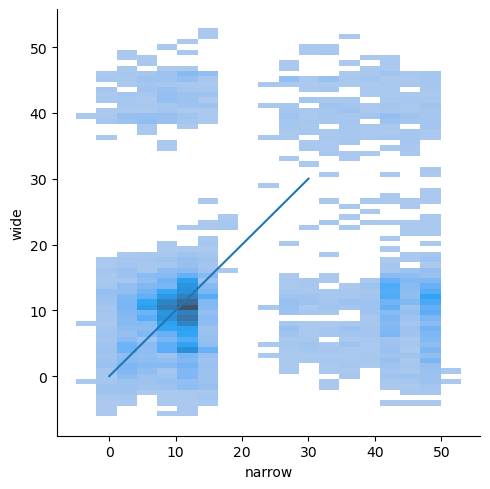

In [ ]:
tmp = pars.xs('Model 2', level='model_label')['mu']
mask = pars.xs('Model 2', level='model_label')['cvr2'] > 0.0

tmp = tmp[mask.values].dropna()

sns.displot(data=tmp, x='narrow', y='wide')
plt.plot([0,30,], [0, 30])

# plt.xlim(0, 20)
# plt.ylim(0, 20)

parameter,mu,sd,amplitude,baseline
parameter,,,,
mu,1.000000,-0.162577,0.056964,-0.229008
sd,-0.162577,1.000000,-0.232724,0.130529
amplitude,0.056964,-0.232724,1.000000,-0.020711
baseline,-0.229008,0.130529,-0.020711,1.000000


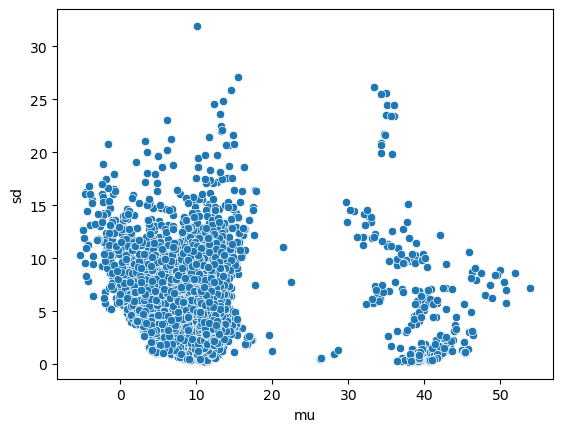

In [ ]:
tmp = pars.xs('Model 1', level='model_label').xs('narrow', axis=1, level='range')
mask = pars.xs('Model 1', level='model_label')['cvr2'] > 0.0

tmp = tmp[mask.values].dropna()
sns.scatterplot(data=tmp, x='mu', y='sd')

tmp.corr()

(0.0, 40.0)

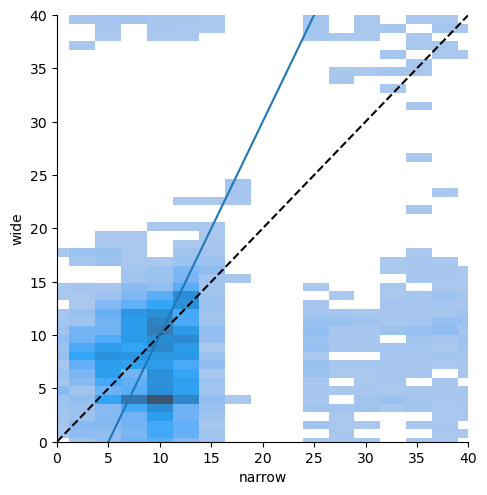

In [ ]:
pars8 = pars.xs('Model 8', level='model_label')

mask = (pars8['cvr2'] > 0.0)

tmp = pars8[mask.values]
# mask.mean()   
sns.displot(x='narrow', y='wide', data=tmp['mu'])

plt.plot([0, 50], [0, 50], 'k--')
plt.plot([0, 50], [0*2-10, 50*2-10])
plt.xlim(0, 40)
plt.ylim(0, 40)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/3966626838.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['narrow_mu_integer'] = tmp['mu']['narrow'].round().astype(int)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_15803/3966626838.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  tmp = tmp.groupby(['subject', 'model_label', 'narrow_mu_integer']).mean()[('cvr2', 'nan')].to_frame('cvr2')


<Axes: xlabel='narrow_mu_integer', ylabel='cvr2'>

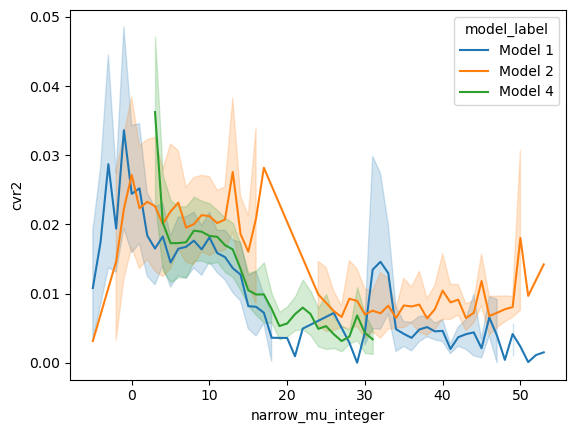

In [ ]:
pars

mask = pars['cvr2'] > 0.0

tmp = pars[mask.values]


tmp['narrow_mu_integer'] = tmp['mu']['narrow'].round().astype(int)

# tmp['narrow_mu_integer']

tmp = tmp.groupby(['subject', 'model_label', 'narrow_mu_integer']).mean()[('cvr2', 'nan')].to_frame('cvr2')

tmp.xs(slice(5, 40), level='narrow_mu_integer')

sns.lineplot(data=tmp.reset_index(), x='narrow_mu_integer', y='cvr2', hue='model_label', hue_order=['Model 1', 'Model 2', 'Model 4'])

cvr2
subject model_label          
1       Model 1      0.021702
        Model 1      0.001739
        Model 1      0.023082
        Model 1      0.017579
        Model 1      0.015790
...                       ...
41      Model 8      0.011849
        Model 8      0.000839
        Model 8      0.012191
        Model 8      0.013906
        Model 8      0.002228

[3837 rows x 1 columns]

In [ ]:
(pars8['cvr2']['nan'] > 0.0) & (pars8['mu']['narrow'] > 10.0)

subject     
1        0      False
         1      False
         2      False
         3      False
         4      False
                ...  
41       689    False
         690    False
         691    False
         692    False
         693    False
Length: 30533, dtype: bool

In [ ]:
pars8 = pars.xs('Model 8', level='model_label')

mask = (pars8['cvr2']['nan'] > 0.0) & (pars8['mu']['narrow'] > 10.0) & (pars8['mu']['wide'] > 10.0) & (pars8['mu']['narrow'] < 25.0) & (pars8['mu', 'wide'] < 35.0)

tmp = pars8[mask.values]
# mask.mean()   
sns.displot(x='narrow', y='wide', data=tmp['sd'])

plt.plot([0, 50], [0, 50], 'k--')
# plt.plot([0, 50], [0*2-10, 50*2-10])
plt.xlim(0, 15)
plt.ylim(0, 15)

plt.figure()
sns.displot(x='narrow', y='wide', data=tmp['mu'])

plt.plot([10, 40], [10, 40], 'k--')

KeyError: 'Model 8'

In [ ]:
from statsmodels.formula import api as smf

Intercept    5.750116
narrow       0.498181
dtype: float64

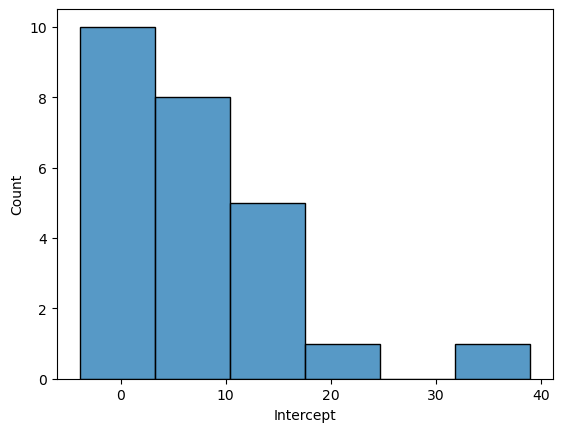

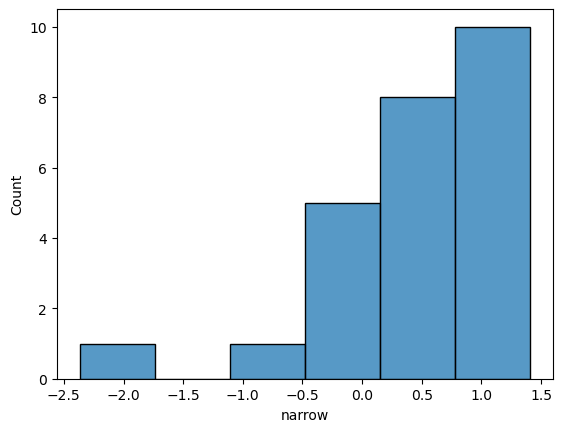

In [ ]:
r = tmp['mu'].groupby('subject').apply(lambda x: smf.ols('wide ~ narrow', data=x).fit().params)

sns.histplot(r['Intercept'])


plt.figure()
sns.histplot(r['narrow'])

r.median()

<Axes: xlabel='narrow', ylabel='Count'>

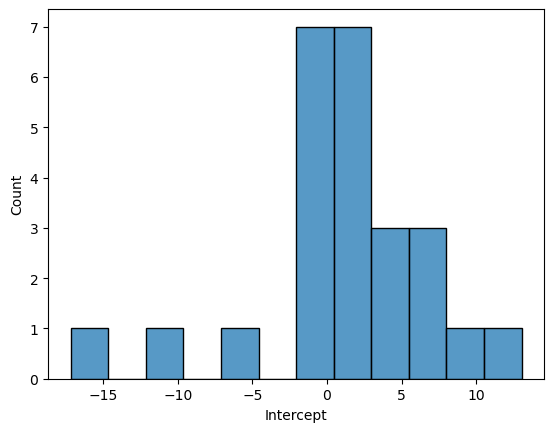

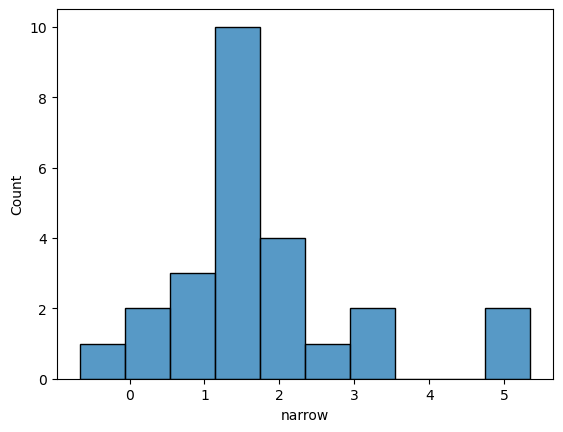

In [ ]:
r = tmp['sd'].groupby('subject').apply(lambda x: smf.ols('wide ~ narrow', data=x).fit().params)

sns.histplot(r['Intercept'])


plt.figure()
sns.histplot(r['narrow'])

<Axes: xlabel='narrow', ylabel='wide'>

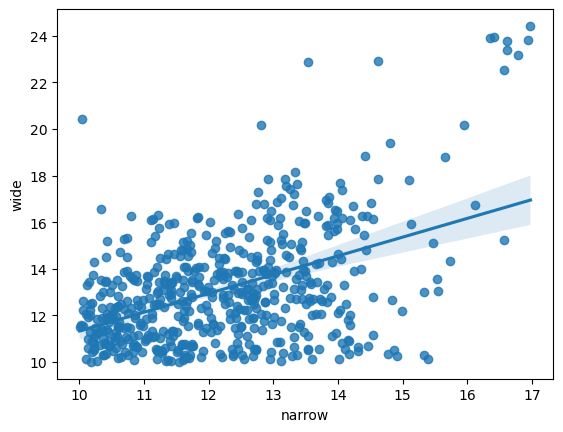

In [ ]:
sns.regplot(data=tmp['mu'], x='narrow', y='wide')

<Axes: xlabel='narrow', ylabel='wide'>

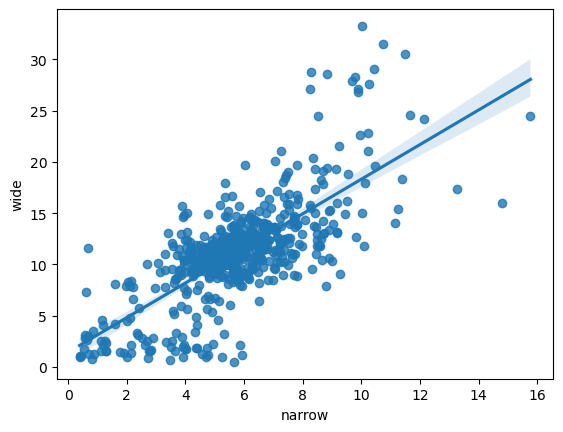

In [ ]:
sns.regplot(data=tmp['sd'], x='narrow', y='wide')

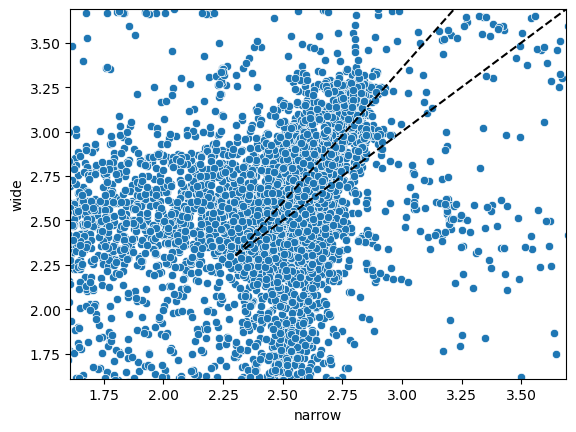

In [ ]:
mask = pars.loc['logspace'].xs(2, level='model_label')['cvr2'] > 0.0

mu = pars.loc['logspace'].xs(2, level='model_label')['mu'][mask.values]


sns.scatterplot(data=mu, x='narrow', y='wide')

plt.xlim(np.log(5), np.log(40))
plt.ylim(np.log(5), np.log(40))


ratio = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))

plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(40)], 'k--')
plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + ratio * (np.log(40) - np.log(10))], 'k--')

In [ ]:
pars

parameter                                  mu                   sd            \
range                                    wide     narrow      wide    narrow   
space    subject model_label voxel                                             
natural  1       1           0      10.943486  10.943486  1.389957  1.389957   
                             1      45.297676  45.297676  1.098172  1.098172   
                             2      45.338240  45.338240  1.067531  1.067531   
                             3      45.309338  45.309338  1.089480  1.089480   
                             4      11.575078  11.575078  1.056056  1.056056   
...                                       ...        ...       ...       ...   
logspace 41      2           689     2.530962   2.507230  1.175538  0.878871   
                             690     2.427509   3.255311  0.033245  2.923490   
                             691     2.534031   2.545920  1.134021  0.923762   
                             692     2.387884   2.165405  0.439514  1.218624   
                             693     2.686459   2.361214  1.083391  1.279126   

parameter                          amplitude            baseline            \
range                                   wide    narrow      wide    narrow   
space    subject model_label voxel                                           
natural  1       1           0      0.293845  0.293845 -0.118108 -0.118108   
                             1      0.034831  0.034831 -0.487767 -0.487767   
                             2      0.028312  0.028312 -0.477014 -0.477014   
                             3      0.035011  0.035011 -0.271681 -0.271681   
                             4      0.374618  0.374618 -0.110368 -0.110368   
...                                      ...       ...       ...       ...   
logspace 41      2           689    0.678985  0.632332 -0.225619 -0.244832   
                             690    0.487090  0.056100  0.258830  0.250432   
                             691    0.598087  0.998646 -0.256018 -0.694834   
                             692    0.164389  0.830690 -0.110820 -0.737721   
                             693    0.576883  0.865316 -0.421084 -0.723382   

parameter                                     r2      cvr2  
range                                        nan       nan  
space    subject model_label voxel                          
natural  1       1           0      8.020937e-03 -0.019104  
                             1     -1.192093e-07 -0.016332  
                             2      0.000000e+00 -0.009276  
                             3     -1.192093e-07 -0.011063  
                             4      8.203387e-03 -0.013769  
...                                          ...       ...  
logspace 41      2           689    2.589977e-02 -0.002525  
                             690    1.388824e-02 -0.016964  
                             691    2.737039e-02  0.008660  
                             692    1.604402e-02 -0.022325  
                             693    1.288181e-02  0.000088  

[382516 rows x 10 columns]

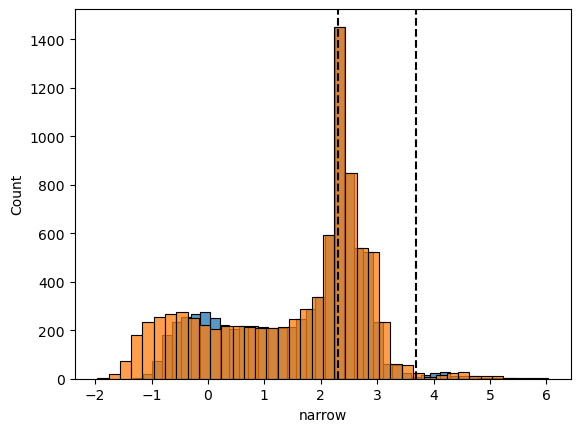

In [ ]:
mask = pars.loc['logspace'].xs(4, level='model_label')['cvr2'] > 0.0
mu = pars.loc['logspace'].xs(4, level='model_label')['mu'][mask.values]
sns.histplot(mu['narrow'])
sns.histplot(mu['wide'])

plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(40), c='k', ls='--')

<Axes: xlabel='narrow', ylabel='Count'>

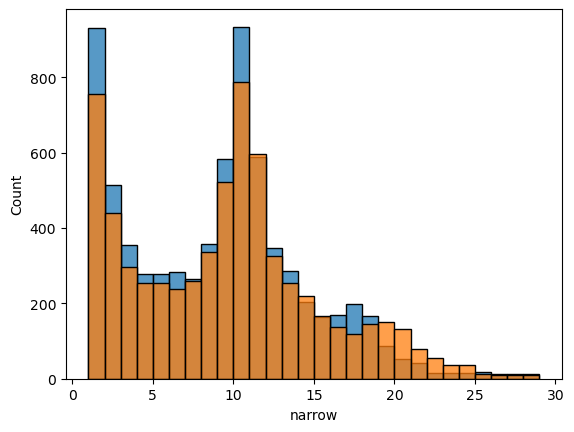

In [ ]:
mu_natural = np.exp(mu)

sns.histplot(mu_natural['narrow'], bins=np.arange(1, 30))
sns.histplot(mu_natural['wide'], bins=np.arange(1, 30))

(0.0, 45.0)

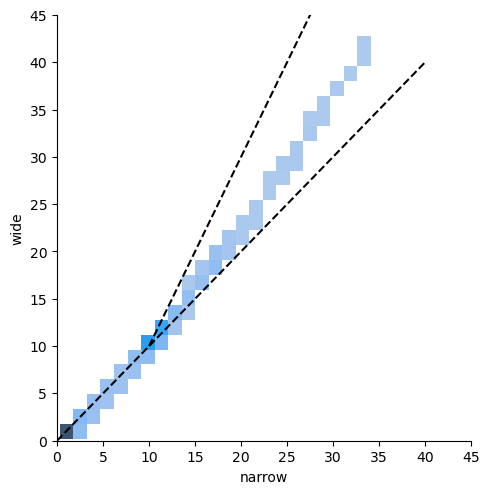

In [ ]:
sns.displot(data=mu_natural, x='narrow', y='wide')
plt.plot([0, 40], [0, 40], 'k--')
plt.plot([10, 40], [10, 10+(40-10)*2], 'k--')

plt.xlim(0, 45)
plt.ylim(0, 45)


<Axes: xlabel='narrow', ylabel='Count'>

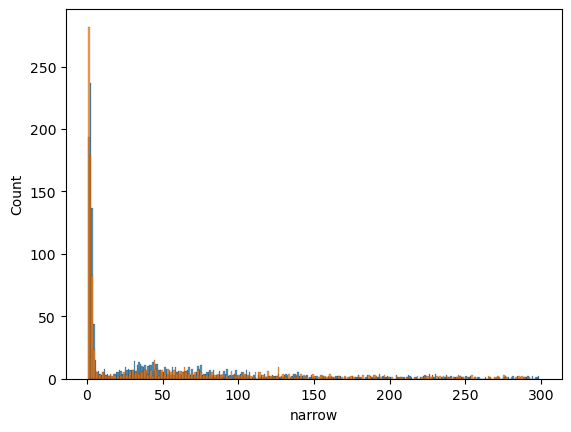

In [ ]:
import numpy as np

def log_gauss_to_natural(mu_log, sigma_log):
    """
    Converts the mean (mu_log) and standard deviation (sigma_log) of a Gaussian 
    in log-space to the corresponding mean (mu) and standard deviation (sigma) 
    of the lognormal distribution in natural space.
    
    Parameters:
        mu_log (float): Mean of the Gaussian in log-space.
        sigma_log (float): Standard deviation of the Gaussian in log-space.
    
    Returns:
        mu (float): Mean of the corresponding lognormal distribution in natural space.
        sigma (float): Standard deviation of the corresponding lognormal distribution in natural space.
    """
    mu_natural = np.exp(mu_log + (sigma_log**2) / 2)
    sigma_natural = np.sqrt((np.exp(sigma_log**2) - 1) * np.exp(2 * mu_log + sigma_log**2))
    
    return mu_natural, sigma_natural

# Example usage
mask = pars.loc['logspace'].xs(4, level='model_label')['cvr2'] > 0.0
mu = pars.loc['logspace'].xs(4, level='model_label')['mu'][mask.values]
sd = pars.loc['logspace'].xs(4, level='model_label')['sd'][mask.values]
mu, sigma = log_gauss_to_natural(mu, sd)

sns.histplot(sigma['narrow'], bins=np.arange(1, 300))
sns.histplot(sigma['wide'], bins=np.arange(1, 300))


In [ ]:
sigma['narrow'].median(), sigma['wide'].median()

(92.69712526151417, 170.2431158834417)

In [ ]:
natural_mean, natural_sd = log_gauss_to_natural(pars['mu'].xs(4, level='model_labal'), pars['sd'].xs(4, level='model_label'))

KeyError: 'Level model_labal not found'

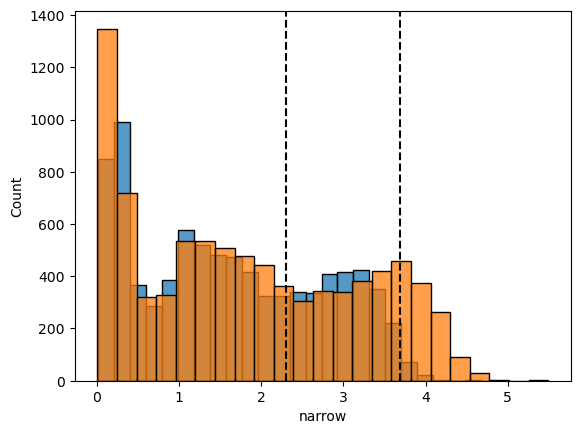

In [ ]:
sd = pars.loc['logspace'].xs(4, level='model_label')['sd'][mask.values]
sns.histplot(sd['narrow'])
sns.histplot(sd['wide'])

plt.axvline(np.log(10), c='k', ls='--')
plt.axvline(np.log(40), c='k', ls='--')

In [ ]:
natural_sd

range                                       wide        narrow
space    subject model_label voxel                            
natural  1       1           0      3.612125e+05  3.612125e+05
                             1      1.315280e+20  1.315280e+20
                             2      1.262854e+20  1.262854e+20
                             3      1.300277e+20  1.300277e+20
                             4      2.661213e+05  2.661213e+05
...                                          ...           ...
logspace 41      2           689    4.330528e+01  1.948789e+01
                             690    3.770011e-01  1.335201e+05
                             691    3.879511e+01  2.268493e+01
                             692    5.537015e+00  3.385335e+01
                             693    3.945799e+01  4.886647e+01

[382516 rows x 2 columns]

In [ ]:
sd = natural_sd.xs(4, level='model_label')

sd

range                           wide        narrow
space    subject voxel                            
natural  1       0      5.528403e+07  1.996284e+05
                 1      1.543681e+05  5.799513e+04
                 2      1.385281e+18  3.278938e+10
                 3      3.243015e+07  7.130229e+05
                 4      2.777080e+05  7.512645e+04
...                              ...           ...
logspace 13      847    2.425688e+00  2.944016e+00
                 848    1.399582e+00  1.841816e+00
                 849    1.921234e+00  2.411432e+00
                 850    8.592357e-01  1.219107e+00
                 851    7.480820e-01  1.084596e+00

[38895 rows x 2 columns]

In [ ]:
natural_sd

range                                       wide        narrow
space    subject model_label voxel                            
natural  1       1           0      3.612125e+05  3.612125e+05
                             1      1.315280e+20  1.315280e+20
                             2      1.262854e+20  1.262854e+20
                             3      1.300277e+20  1.300277e+20
                             4      2.661213e+05  2.661213e+05
...                                          ...           ...
logspace 41      2           689    4.330528e+01  1.948789e+01
                             690    3.770011e-01  1.335201e+05
                             691    3.879511e+01  2.268493e+01
                             692    5.537015e+00  3.385335e+01
                             693    3.945799e+01  4.886647e+01

[382516 rows x 2 columns]

In [220]:
print(set(x[0] for x in pars.columns))


{'r2', 'mu', 'cvr2', 'baseline', 'amplitude', 'sd'}


In [222]:
p

mu_wide  mu_narrow    sd_wide  sd_narrow  amplitude_wide  \
subject voxel                                                               
1       0      11.595240  25.648548   0.393298   0.312848        1.140289   
        1      11.636940  26.851240   0.344287   0.753157        1.251556   
        2       8.937398  26.438684   0.413720   0.559094        4.534775   
        3       8.659326  26.162928   0.512179   0.451578        3.011373   
        4      11.835389   9.990706   1.453340   0.223928        0.512227   
...                  ...        ...        ...        ...             ...   
41      689     9.032573  50.753273   8.418471   9.157082        0.172773   
        690     6.559924  42.357677   5.654643  20.029196        0.098891   
        691     9.956812  50.080322   7.728835   7.668187        0.155963   
        692     9.015952  45.013040   5.653810   2.971829        0.114982   
        693    14.492903   8.346853  10.883977   8.846796        0.194781   

               amplitude_narrow  baseline_wide  baseline_narrow        r2  \
subject voxel                                                               
1       0              1.140289      -0.097208        -0.097208  0.008772   
        1              1.251556      -0.504301        -0.504301  0.008609   
        2              4.534775      -0.486710        -0.486710  0.002919   
        3              3.011373      -0.277817        -0.277817  0.001346   
        4              0.512227      -0.115505        -0.115505  0.015846   
...                         ...            ...              ...       ...   
41      689            0.172773       0.305354         0.305354  0.011650   
        690            0.098891       0.258656         0.258656  0.005337   
        691            0.155963       0.206769         0.206769  0.009574   
        692            0.114982      -0.055355        -0.055355  0.002475   
        693            0.194781      -0.040231        -0.040231  0.012021   

                   cvr2  
subject voxel            
1       0     -0.036828  
        1     -0.013965  
        2     -0.032658  
        3     -0.022744  
        4     -0.033635  
...                 ...  
41      689   -0.010526  
        690   -0.014687  
        691   -0.013309  
        692   -0.024659  
        693   -0.000806  

[30533 rows x 10 columns]

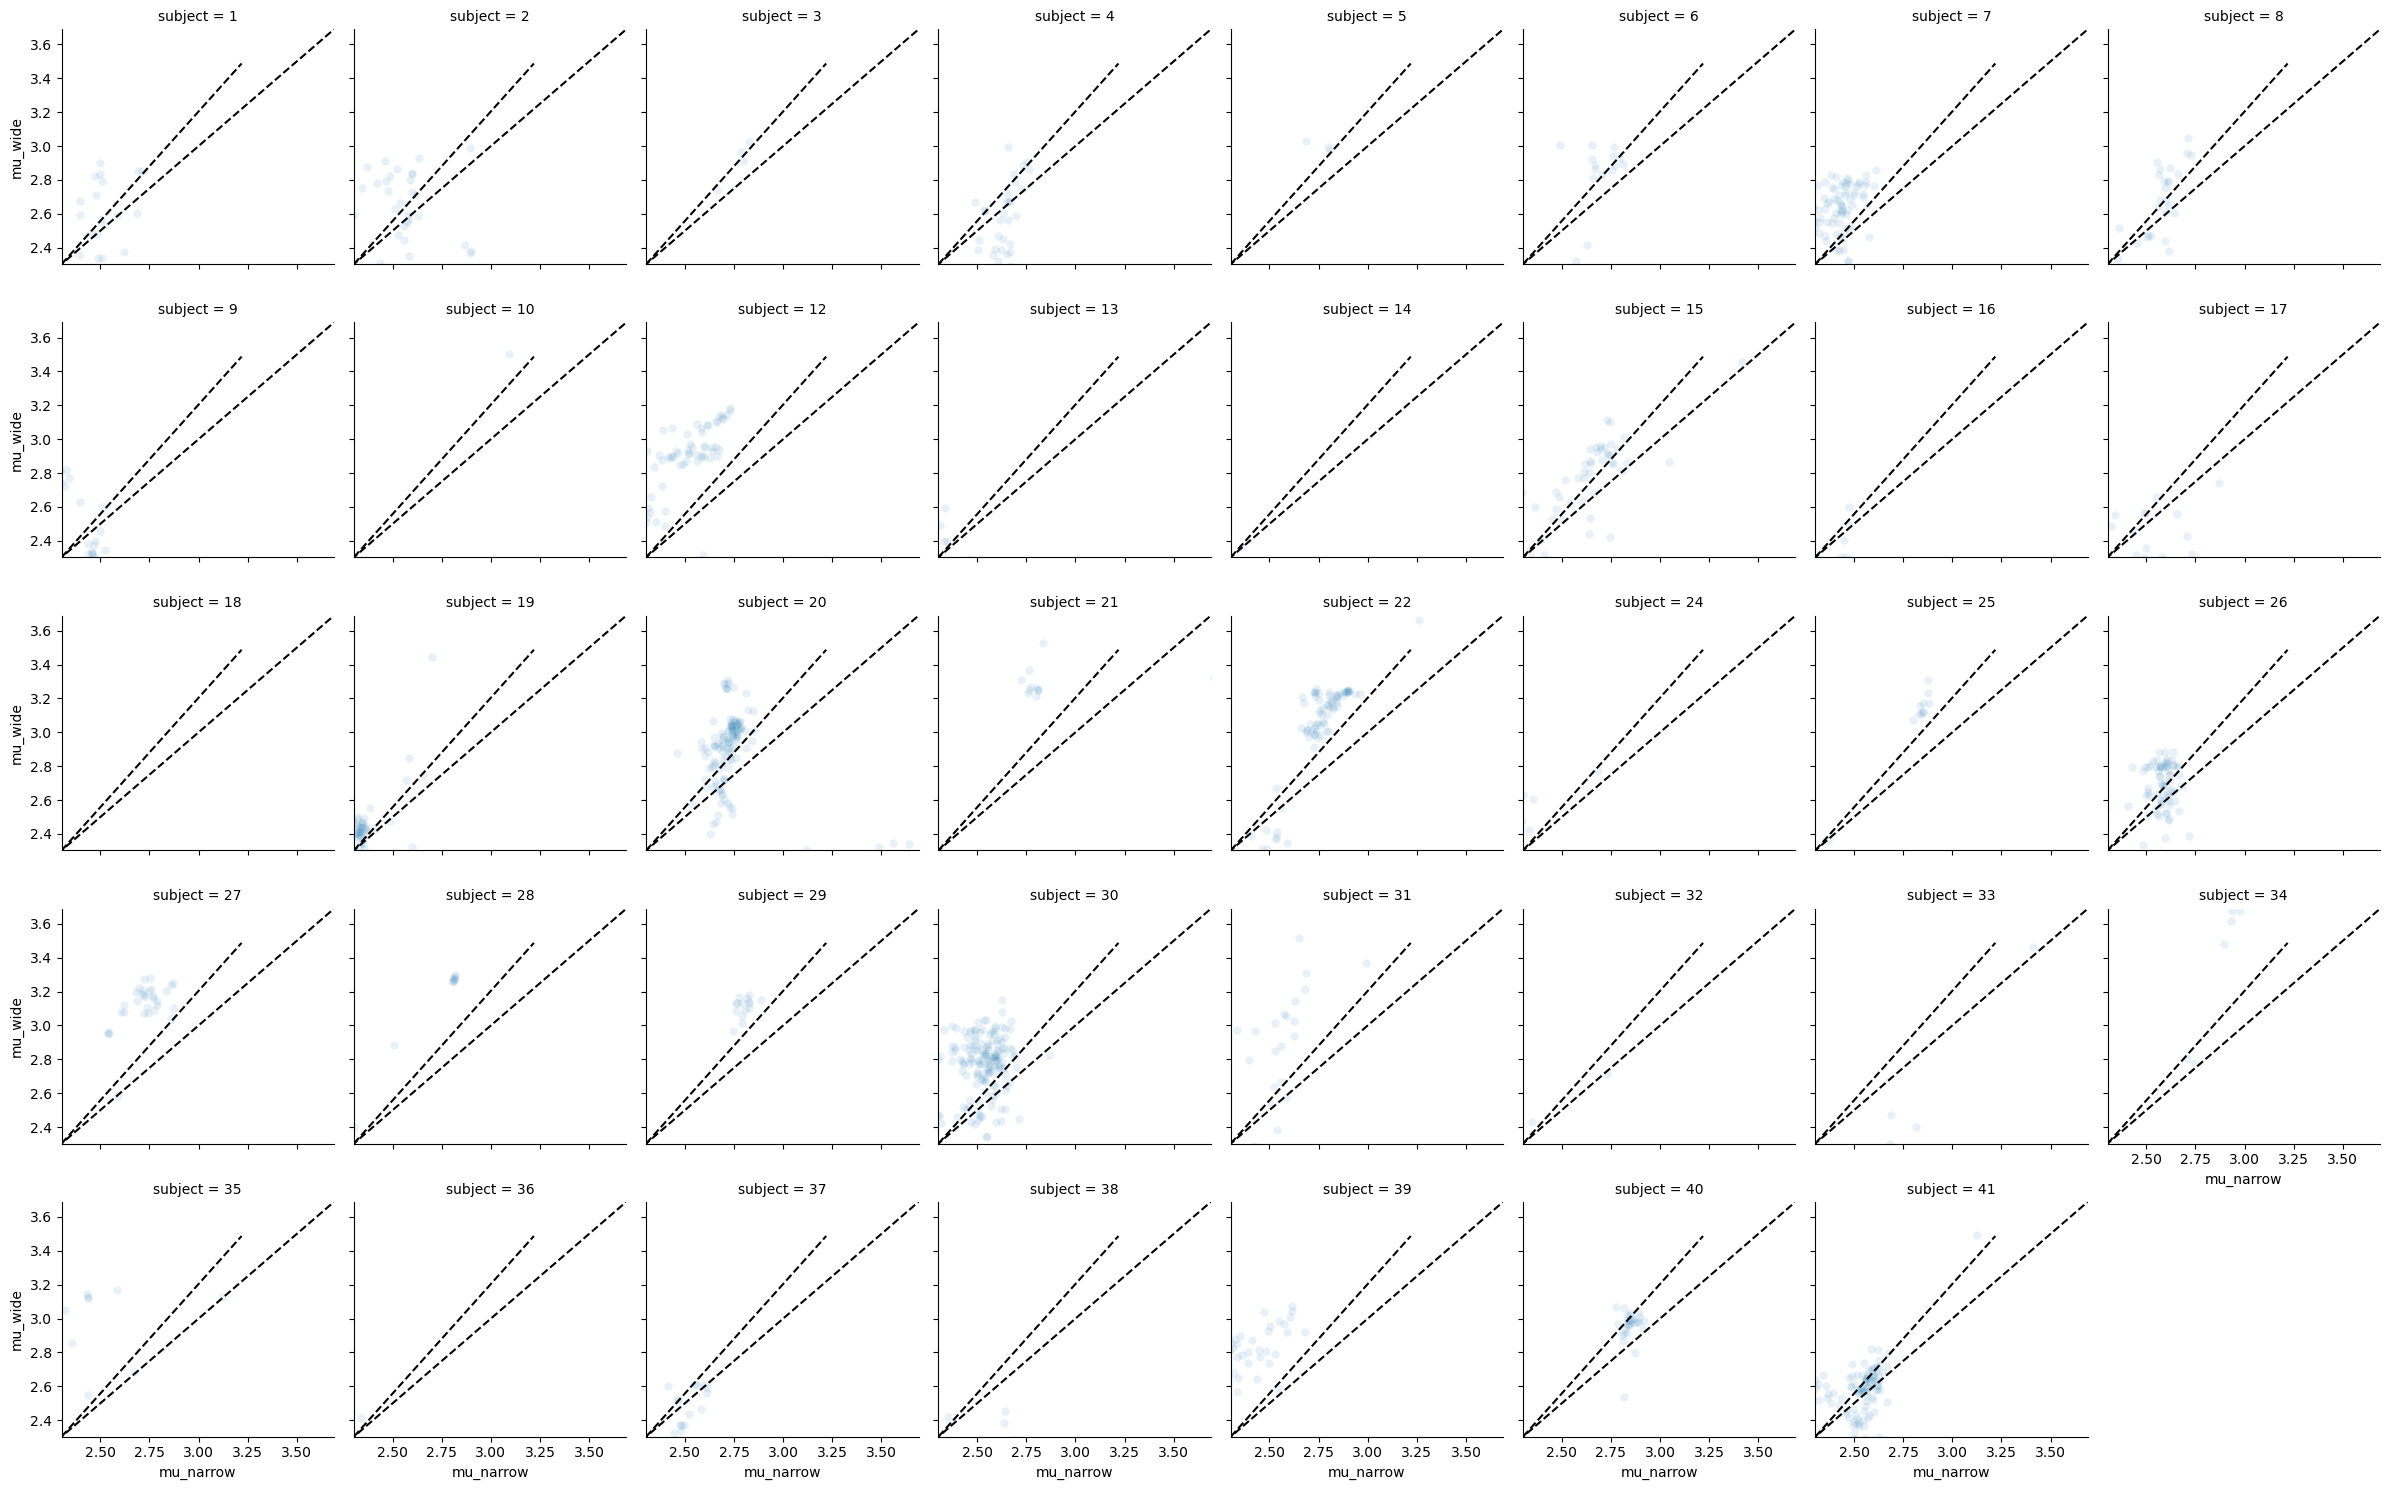

In [231]:
p = pars.loc[('logspace', slice(None), 8)]

p.columns = [f'{x[0]}_{x[1]}' if x[0] not in ['r2', 'cvr2'] else x[0] for x in p.columns]

p = p[p.cvr2 > 0.0]

g = sns.FacetGrid(p.reset_index(), col='subject', col_wrap=8)

g.map(sns.scatterplot, 'mu_narrow', 'mu_wide', alpha=0.1)

g.set(xlim=(np.log(10), np.log(40)), ylim=(np.log(10), np.log(40)))

g.map_dataframe(lambda data, **kwargs: plt.plot(np.log([5, 40]), np.log([5, 40]), ls='--', c='k'))
slope = (np.log(40) - np.log(10)) / (np.log(25) - np.log(10))
g.map_dataframe(lambda data, **kwargs: plt.plot(np.log([10, 25]), np.log([10, 10 + slope * (25 - 10)]), ls='--', c='k'))

In [ ]:
import bambi

In [ ]:
p

mu_wide  mu_narrow    sd_wide  sd_narrow  amplitude_wide  \
subject voxel                                                               
1       0      11.595240  25.648548   0.393298   0.312848        1.140289   
        1      11.636940  26.851240   0.344287   0.753157        1.251556   
        2       8.937398  26.438684   0.413720   0.559094        4.534775   
        3       8.659326  26.162928   0.512179   0.451578        3.011373   
        4      11.835389   9.990706   1.453340   0.223928        0.512227   
...                  ...        ...        ...        ...             ...   
41      689     9.032573  50.753273   8.418471   9.157082        0.172773   
        690     6.559924  42.357677   5.654643  20.029196        0.098891   
        691     9.956812  50.080322   7.728835   7.668187        0.155963   
        692     9.015952  45.013040   5.653810   2.971829        0.114982   
        693    14.492903   8.346853  10.883977   8.846796        0.194781   

               amplitude_narrow  baseline_wide  baseline_narrow        r2  \
subject voxel                                                               
1       0              1.140289      -0.097208        -0.097208  0.008772   
        1              1.251556      -0.504301        -0.504301  0.008609   
        2              4.534775      -0.486710        -0.486710  0.002919   
        3              3.011373      -0.277817        -0.277817  0.001346   
        4              0.512227      -0.115505        -0.115505  0.015846   
...                         ...            ...              ...       ...   
41      689            0.172773       0.305354         0.305354  0.011650   
        690            0.098891       0.258656         0.258656  0.005337   
        691            0.155963       0.206769         0.206769  0.009574   
        692            0.114982      -0.055355        -0.055355  0.002475   
        693            0.194781      -0.040231        -0.040231  0.012021   

               cvr2_nan  
subject voxel            
1       0     -0.036828  
        1     -0.013965  
        2     -0.032658  
        3     -0.022744  
        4     -0.033635  
...                 ...  
41      689   -0.010526  
        690   -0.014687  
        691   -0.013309  
        692   -0.024659  
        693   -0.000806  

[30533 rows x 10 columns]

In [ ]:
p

mu_wide  mu_narrow    sd_wide  sd_narrow  amplitude_wide  \
subject voxel                                                               
1       0      11.595240  25.648548   0.393298   0.312848        1.140289   
        1      11.636940  26.851240   0.344287   0.753157        1.251556   
        2       8.937398  26.438684   0.413720   0.559094        4.534775   
        3       8.659326  26.162928   0.512179   0.451578        3.011373   
        4      11.835389   9.990706   1.453340   0.223928        0.512227   
...                  ...        ...        ...        ...             ...   
41      689     9.032573  50.753273   8.418471   9.157082        0.172773   
        690     6.559924  42.357677   5.654643  20.029196        0.098891   
        691     9.956812  50.080322   7.728835   7.668187        0.155963   
        692     9.015952  45.013040   5.653810   2.971829        0.114982   
        693    14.492903   8.346853  10.883977   8.846796        0.194781   

               amplitude_narrow  baseline_wide  baseline_narrow        r2  \
subject voxel                                                               
1       0              1.140289      -0.097208        -0.097208  0.008772   
        1              1.251556      -0.504301        -0.504301  0.008609   
        2              4.534775      -0.486710        -0.486710  0.002919   
        3              3.011373      -0.277817        -0.277817  0.001346   
        4              0.512227      -0.115505        -0.115505  0.015846   
...                         ...            ...              ...       ...   
41      689            0.172773       0.305354         0.305354  0.011650   
        690            0.098891       0.258656         0.258656  0.005337   
        691            0.155963       0.206769         0.206769  0.009574   
        692            0.114982      -0.055355        -0.055355  0.002475   
        693            0.194781      -0.040231        -0.040231  0.012021   

               cvr2_nan  
subject voxel            
1       0     -0.036828  
        1     -0.013965  
        2     -0.032658  
        3     -0.022744  
        4     -0.033635  
...                 ...  
41      689   -0.010526  
        690   -0.014687  
        691   -0.013309  
        692   -0.024659  
        693   -0.000806  

[30533 rows x 10 columns]